Loading final_phishing_dataset.csv...
Total samples: 25108
Class distribution:
label
0    16372
1     8736
Name: count, dtype: int64
Language distribution:
language
English    17537
Hindi       5132
Nepali      2439
Name: count, dtype: int64


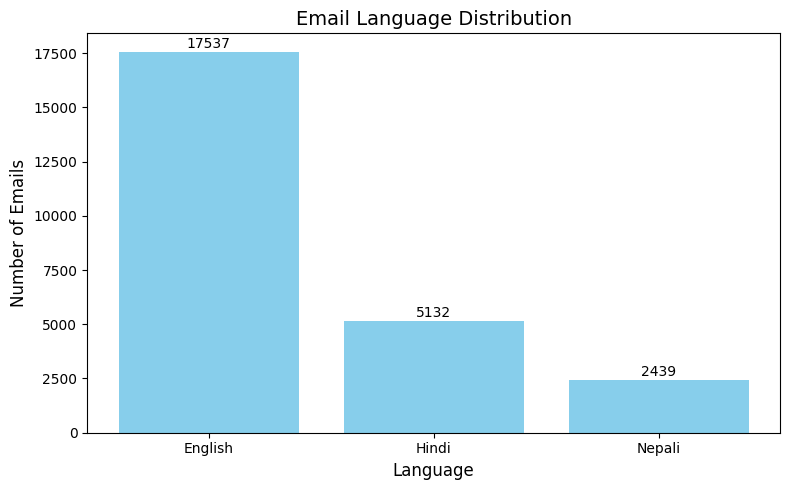

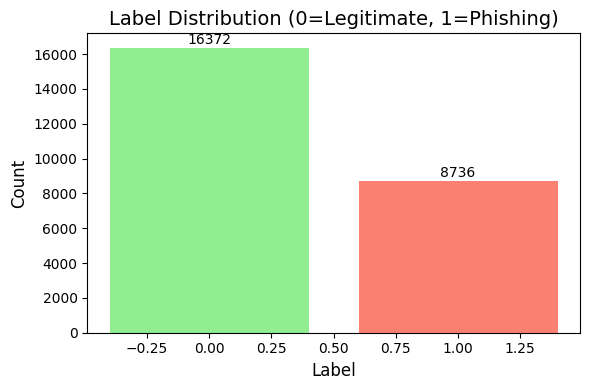

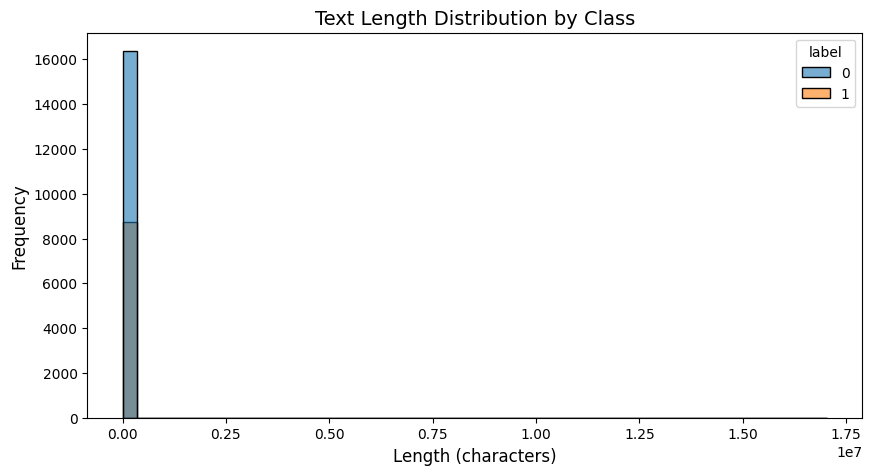

Train: 18077, Val: 2009, Test: 5022
Fitting feature union...
Training feature shape: (18077, 18008)
Scale pos weight: 1.8739
Training XGBoost...
[0]	validation_0-logloss:0.64407	validation_1-logloss:0.64658
[1]	validation_0-logloss:0.60479	validation_1-logloss:0.60778
[2]	validation_0-logloss:0.56923	validation_1-logloss:0.57270
[3]	validation_0-logloss:0.53699	validation_1-logloss:0.54187
[4]	validation_0-logloss:0.50994	validation_1-logloss:0.51562
[5]	validation_0-logloss:0.48537	validation_1-logloss:0.49186
[6]	validation_0-logloss:0.46264	validation_1-logloss:0.47128
[7]	validation_0-logloss:0.44226	validation_1-logloss:0.45199
[8]	validation_0-logloss:0.42370	validation_1-logloss:0.43358
[9]	validation_0-logloss:0.40640	validation_1-logloss:0.41691
[10]	validation_0-logloss:0.39099	validation_1-logloss:0.40052
[11]	validation_0-logloss:0.37824	validation_1-logloss:0.38834
[12]	validation_0-logloss:0.36360	validation_1-logloss:0.37390
[13]	validation_0-logloss:0.35340	validation_1

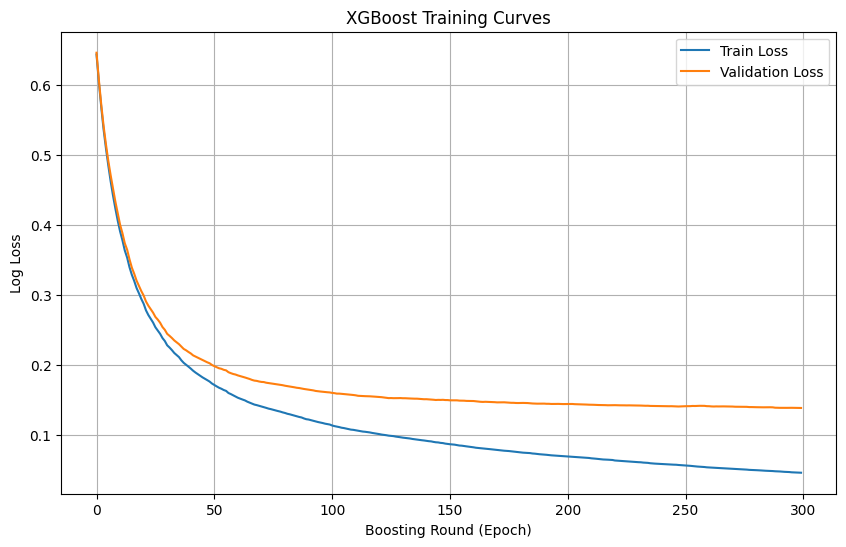


Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97      3275
    Phishing       0.94      0.94      0.94      1747

    accuracy                           0.96      5022
   macro avg       0.95      0.95      0.95      5022
weighted avg       0.96      0.96      0.96      5022

F1 Score: 0.9386


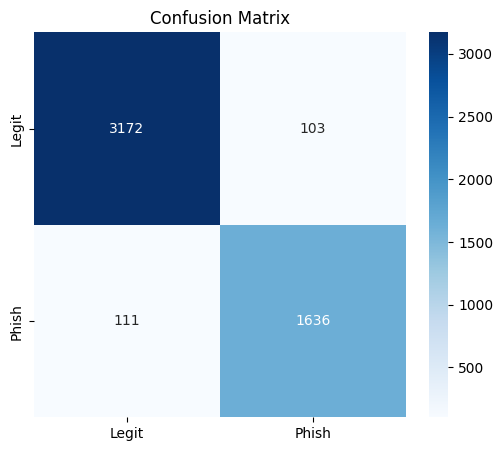

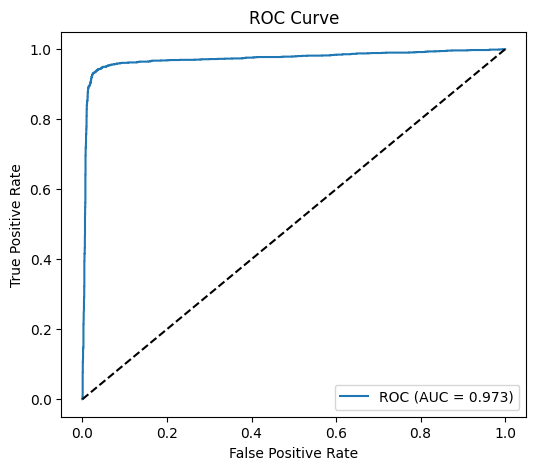

Pipeline saved as phishing_model.pkl

✅ All done! Figures saved in 'figures/' directory.


In [10]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

os.makedirs("figures", exist_ok=True)

# ==========================
# 1. Load dataset
# ==========================
print("Loading final_phishing_dataset.csv...")
df = pd.read_csv("final_phishing_dataset.csv")
df = df[['text', 'label', 'language']].dropna()
df['label'] = df['label'].astype(int)
print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['label'].value_counts()}")
print(f"Language distribution:\n{df['language'].value_counts()}")

# ==========================
# 2. Language distribution
# ==========================
lang_counts = df['language'].value_counts()
plt.figure(figsize=(8,5))
bars = plt.bar(lang_counts.index, lang_counts.values, color='skyblue')
plt.title('Email Language Distribution', fontsize=14)
plt.xlabel('Language', fontsize=12)
plt.ylabel('Number of Emails', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("figures/language_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 3. Label distribution
# ==========================
label_counts = df['label'].value_counts()
plt.figure(figsize=(6,4))
bars = plt.bar(label_counts.index, label_counts.values, color=['lightgreen', 'salmon'])
plt.title('Label Distribution (0=Legitimate, 1=Phishing)', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig("figures/label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 4. Text length distribution
# ==========================
df['text_len'] = df['text'].str.len()
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='text_len', hue='label', bins=50, alpha=0.6)
plt.title('Text Length Distribution by Class', fontsize=14)
plt.xlabel('Length (characters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig("figures/text_length_dist.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 5. Feature engineering
# ==========================
def entropy(s):
    if len(s) == 0:
        return 0
    prob = [s.count(c)/len(s) for c in set(s)]
    return -sum(p * np.log2(p) for p in prob)

def extra_features(text):
    features = {}
    features['length'] = len(text)
    features['num_digits'] = sum(c.isdigit() for c in text)
    features['num_special'] = sum(not c.isalnum() and not c.isspace() for c in text)
    features['num_urls'] = len(re.findall(r'https?://\S+|www\.\S+', text))
    features['num_exclamations'] = text.count('!')
    features['num_uppercase_words'] = sum(1 for w in text.split() if w.isupper() and len(w)>1)
    features['entropy'] = entropy(text)
    
    suspicious_en = ['verify','account','login','update','bank','paypal','secure','click','confirm','urgent','password']
    suspicious_ne = ['खाता','प्रमाणित','लगइन','अपडेट','बैंक','सुरक्षित','क्लिक','पुष्टि','अत्यावश्यक','पासवर्ड']
    features['has_suspicious'] = int(any(kw in text.lower() for kw in suspicious_en) or
                                     any(kw in text for kw in suspicious_ne))
    return features

class ExtraFeaturesTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return pd.DataFrame([extra_features(t) for t in X]).values

# ==========================
# 6. Split data
# ==========================
X = df['text'].tolist()
y = df['label'].tolist()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=42, stratify=y_train_val
)

# Convert to numpy arrays for easy counting
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ==========================
# 7. Feature Union
# ==========================
char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    max_features=12000,
    sublinear_tf=True,
    lowercase=True
)

word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=6000,
    sublinear_tf=True,
    lowercase=True,
    stop_words='english'
)

combined = FeatureUnion([
    ('char', char_vectorizer),
    ('word', word_vectorizer),
    ('extra', ExtraFeaturesTransformer())
])

print("Fitting feature union...")
combined.fit(X_train)
X_train_feat = combined.transform(X_train)
X_val_feat = combined.transform(X_val)
X_test_feat = combined.transform(X_test)
print(f"Training feature shape: {X_train_feat.shape}")

# ==========================
# 8. XGBoost with regularisation
# ==========================
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"Scale pos weight: {scale_pos_weight:.4f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=20,
    scale_pos_weight=scale_pos_weight
)

eval_set = [(X_train_feat, y_train), (X_val_feat, y_val)]
print("Training XGBoost...")
model.fit(X_train_feat, y_train, eval_set=eval_set, verbose=True)

# ==========================
# 9. Training curves
# ==========================
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10,6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss')
plt.xlabel('Boosting Round (Epoch)')
plt.ylabel('Log Loss')
plt.title('XGBoost Training Curves')
plt.legend()
plt.grid(True)
plt.savefig("figures/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 10. Evaluation
# ==========================
y_pred = model.predict(X_test_feat)
y_proba = model.predict_proba(X_test_feat)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate','Phishing']))
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
plt.title('Confusion Matrix')
plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("figures/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================
# 11. Save model and results
# ==========================
full_pipeline = Pipeline([
    ('features', combined),
    ('clf', model)
])
joblib.dump(full_pipeline, 'phishing_model.pkl')
print("Pipeline saved as phishing_model.pkl")

with open("model_results.txt", "w") as f:
    f.write("Classification Report\n")
    f.write(classification_report(y_test, y_pred, target_names=['Legitimate','Phishing']))
    f.write(f"\nF1 Score: {f1:.4f}\n")
    f.write(f"ROC AUC: {roc_auc:.4f}\n")

print("\n✅ All done! Figures saved in 'figures/' directory.")

In [11]:
import joblib
model = joblib.load('phishing_model.pkl')
print(type(model))
print(model.named_steps['clf'].n_estimators)  # number of trees

<class 'sklearn.pipeline.Pipeline'>
300
